In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("masters2026.csv")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (91, 5)


,player,R1,R2,R3,R4
0,Rory McIlroy,67,65,73,71
1,Scottie Scheffler,70,74,65,68
2,Justin Rose,70,69,69,70
3,Cameron Young,73,67,65,73
4,Tyrrell Hatton,74,66,72,66


In [3]:
# Convert R3 and R4 to numeric, turning missing values / cut symbols ('-') into NaN
round_cols = ["R1", "R2", "R3", "R4"]
for col in round_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    
print(f"Total starting players: {len(df)}")
print(f"Players who made the cut (completed 4 rounds): {df['R3'].notna().sum()}")
df.head()

Total starting players: 91
Players who made the cut (completed 4 rounds): 54


,player,R1,R2,R3,R4
0,Rory McIlroy,67,65,73.0,71.0
1,Scottie Scheffler,70,74,65.0,68.0
2,Justin Rose,70,69,69.0,70.0
3,Cameron Young,73,67,65.0,73.0
4,Tyrrell Hatton,74,66,72.0,66.0


In [4]:
summary_stats = df[round_cols].describe().T
print(summary_stats)

    count       mean       std   min   25%   50%   75%   max
R1   91.0  74.648352  3.640432  67.0  72.0  74.0  77.0  84.0
R2   91.0  72.846154  3.441328  65.0  70.0  73.0  75.0  81.0
R3   54.0  70.629630  2.756100  65.0  69.0  70.0  72.0  78.0
R4   54.0  72.092593  3.737967  66.0  69.0  72.0  75.0  80.0


In [5]:
model= smf.ols('R2 ~ R1', data=df).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                     R2   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     17.59
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           6.45e-05
Time:                        13:10:40   Log-Likelihood:                -232.88
No. Observations:                  91   AIC:                             469.8
Df Residuals:                      89   BIC:                             474.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     44.1773      6.843      6.456      0.0

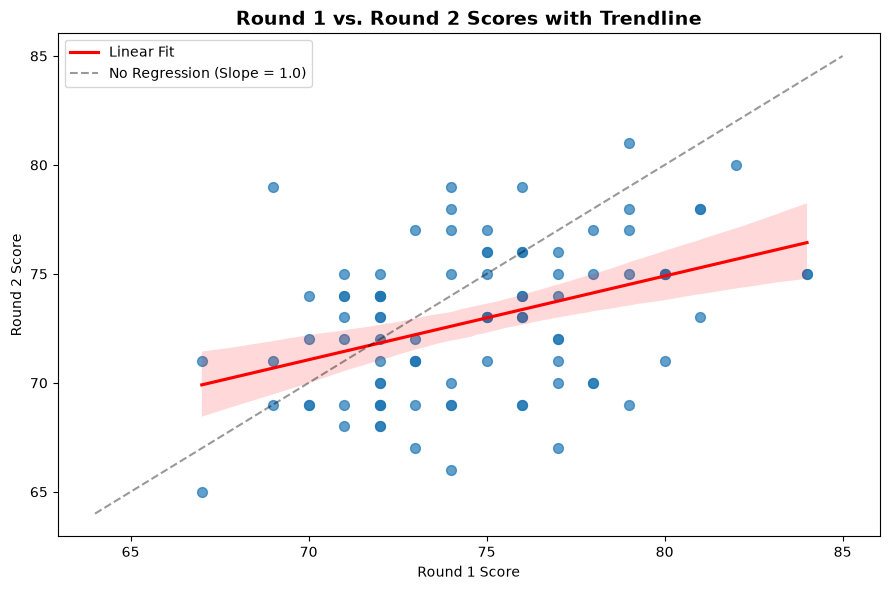

Fitted Slope: 0.384
Interpretation: For every 1-stroke improvement below the mean in R1, players only retained ~0.38 strokes of that improvement in R2.


In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(
    data=df, 
    x="R1", 
    y="R2", 
    ax=ax, 
    scatter_kws={"alpha": 0.7, "s": 50}, 
    line_kws={"color": "red", "label": "Linear Fit"}
)

# Reference 1:1 identity line
min_val = min(df["R1"].min(), df["R2"].min()) - 1
max_val = max(df["R1"].max(), df["R2"].max()) + 1
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.4, label="No Regression (Slope = 1.0)")

ax.set_title("Round 1 vs. Round 2 Scores with Trendline", fontsize=14, fontweight="bold")
ax.set_xlabel("Round 1 Score")
ax.set_ylabel("Round 2 Score")
ax.legend()
plt.tight_layout()
plt.show()

# Fit slope calculation
slope, intercept = np.polyfit(df["R1"], df["R2"], 1)
print(f"Fitted Slope: {slope:.3f}")
print(f"Interpretation: For every 1-stroke improvement below the mean in R1, players only retained ~{slope:.2f} strokes of that improvement in R2.")

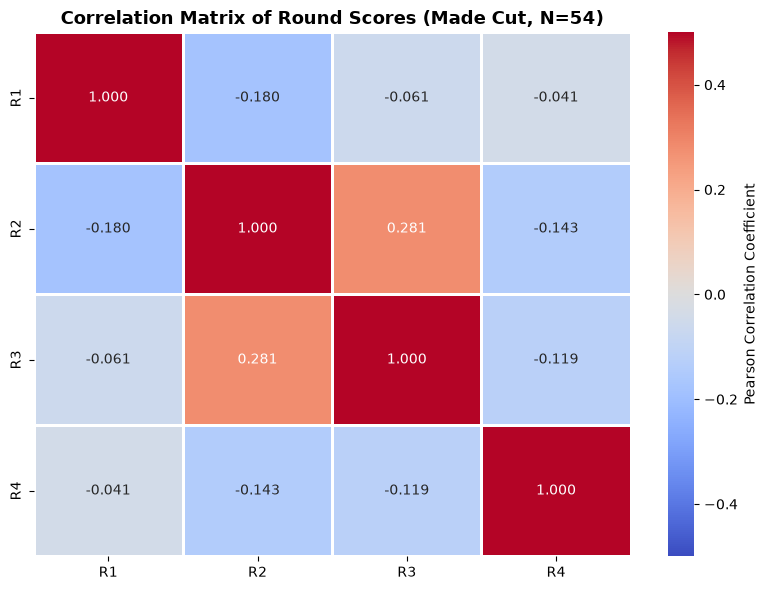

In [7]:
df_cut = df.dropna(subset=["R3"]).copy()

df_cut_rounds = df_cut[["R1", "R2", "R3", "R4"]]

# 3. Calculate Pearson correlation matrix
corr_matrix = df_cut_rounds.corr()

# note Berkson paradox for R1,R2 correlations among players that made the cut

# 4. Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Display numeric correlation values
    fmt=".3f",           # Format numbers to 3 decimal places
    cmap="coolwarm",     # Color palette (blue = negative, red = positive)
    vmin=-0.5,           # Set colorbar lower limit
    vmax=0.5,            # Set colorbar upper limit
    linewidths=1,        # Gridline spacing between cells
    cbar_kws={"label": "Pearson Correlation Coefficient"}
)

plt.title("Correlation Matrix of Round Scores (Made Cut, N=54)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
df_cut = df.dropna(subset=["R3"]).copy()
X = df_cut[["R1", "R2", "R3"]]
y = df_cut["R4"]

# Add intercept for OLS regression
X_const = sm.add_constant(X)

# 3. Fit OLS Model
model = sm.OLS(y, X_const).fit()

# Display full regression output
print(model.summary())


y_pred = model.predict(X_const)

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} strokes")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} strokes")
print(f"R-squared (R²): {r2:.4f}")

                            OLS Regression Results                            
Dep. Variable:                     R4   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                 -0.026
Method:                 Least Squares   F-statistic:                    0.5509
Date:                Thu, 17 Sep 2026   Prob (F-statistic):              0.650
Time:                        13:10:40   Log-Likelihood:                -146.44
No. Observations:                  54   AIC:                             300.9
Df Residuals:                      50   BIC:                             308.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        100.8897     24.368      4.140      0.0

In [9]:
model= smf.ols('R3 ~ R1', data=df_cut).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     R3   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.1948
Date:                Thu, 17 Sep 2026   Prob (F-statistic):              0.661
Time:                        13:10:40   Log-Likelihood:                -130.76
No. Observations:                  54   AIC:                             265.5
Df Residuals:                      52   BIC:                             269.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     75.2926     10.571      7.123      0.0